In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("Automobile_data.csv")

In [3]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [4]:
print(df.shape)

(205, 26)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [6]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [7]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [8]:
df.replace("?", np.nan, inplace=True)

In [9]:
for col in df.columns:

    if df[col].dtype == "object":

        df[col].fillna(
            df[col].mode()[0],
            inplace=True
        )

In [10]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [11]:
df["price"] = pd.to_numeric(df["price"])

In [12]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "object":

        df[col] = le.fit_transform(
            df[col].astype(str)
        )

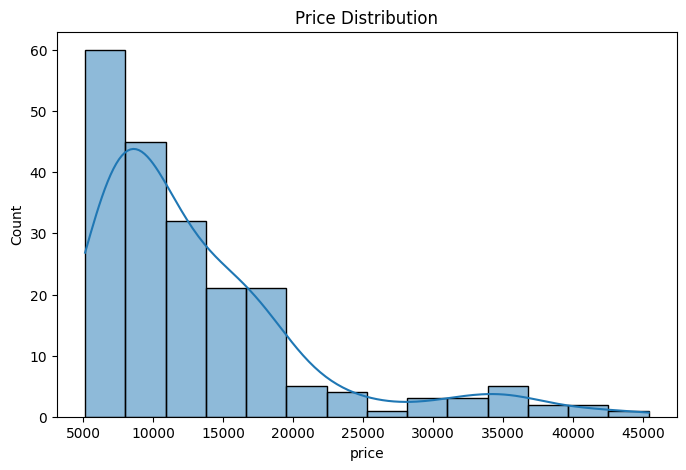

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    kde=True
)

plt.title("Price Distribution")

plt.show()

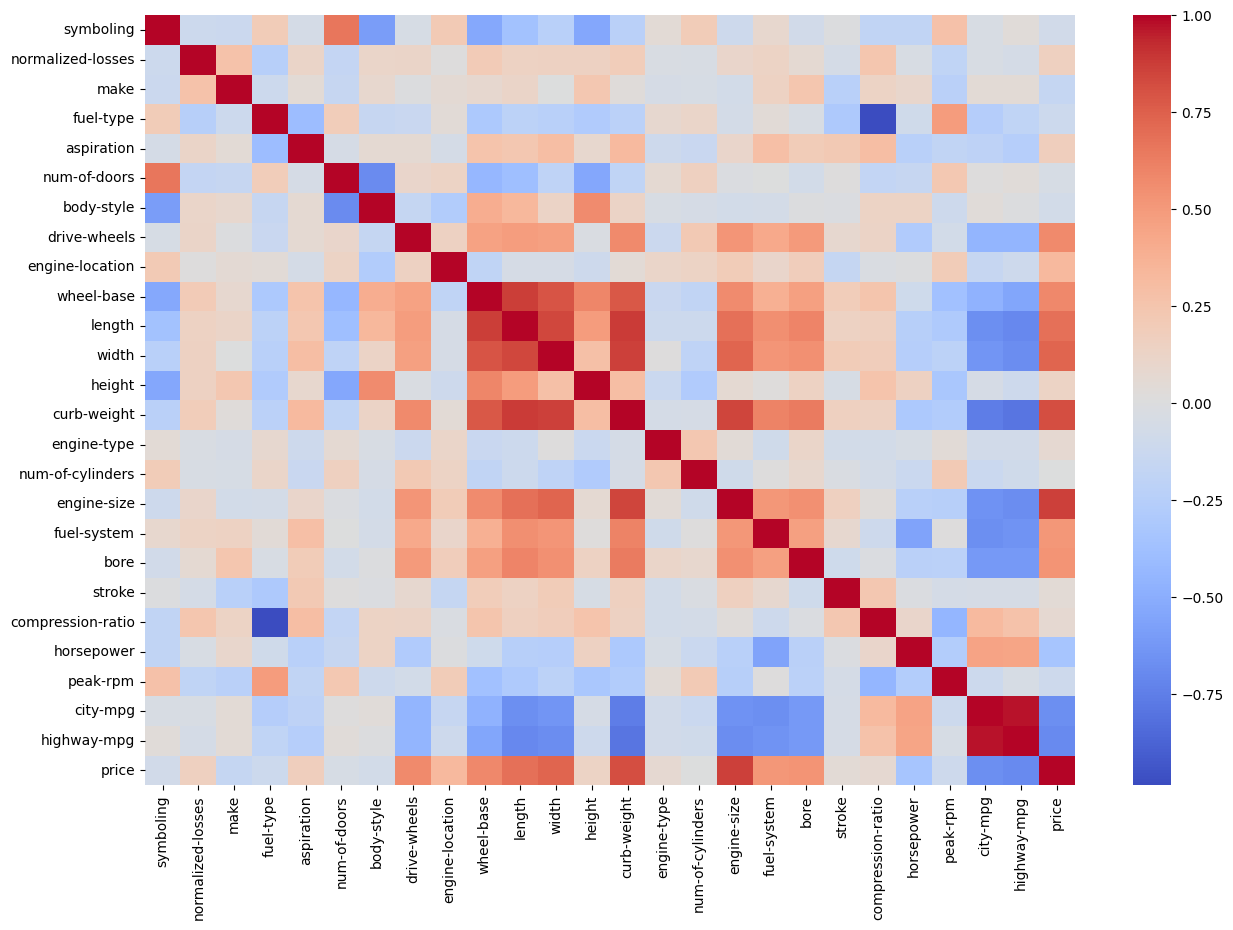

In [14]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

In [15]:
X = df.drop("price", axis=1)

y = df["price"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

In [18]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
lr_pred = lr.predict(X_test)

In [20]:
print("Linear Regression Results")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        lr_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            lr_pred
        )
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        lr_pred
    )
)

Linear Regression Results
MAE: 2355.3654684213498
RMSE: 3607.856322564609
R2 Score: 0.8330521595340491


In [21]:
rf = RandomForestRegressor(

    n_estimators=100,

    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
rf_pred = rf.predict(X_test)

In [23]:
print("Random Forest Results")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        rf_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            rf_pred
        )
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        rf_pred
    )
)

Random Forest Results
MAE: 1590.006910569106
RMSE: 2293.271285467346
R2 Score: 0.9325482527697501


In [24]:
print(
    "Linear Regression R2 =",
    r2_score(
        y_test,
        lr_pred
    )
)

print(
    "Random Forest R2 =",
    r2_score(
        y_test,
        rf_pred
    )
)

Linear Regression R2 = 0.8330521595340491
Random Forest R2 = 0.9325482527697501


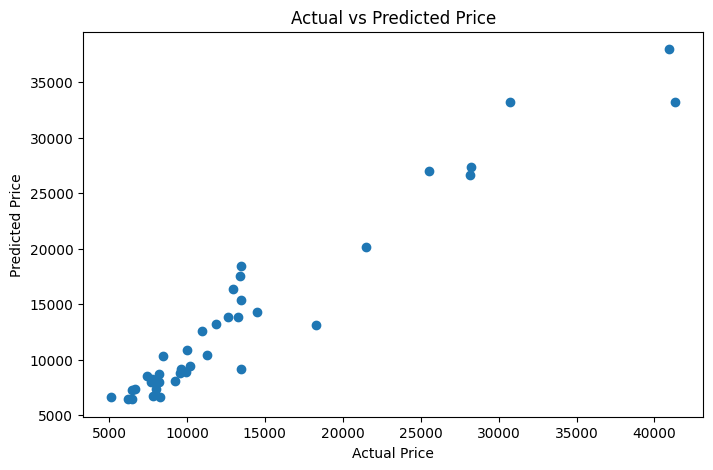

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Actual vs Predicted Price"
)

plt.show()

In [28]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print(
    "Predicted Price =",
    prediction[0]
)

Predicted Price = 14860.255833333335
